# Predicting Diabetes Using Naive Bayes

### Objective
- Apply Naive Bayes for binary classification.
- Practice data exploration and preprocessing.
- Evaluate model performance using appropriate metrics.
- Understand and interpret the log probabilities used in Naive Bayes.

### Dataset
This lab uses the Pima Indians Diabetes Dataset from the UCI Machine Learning Repository. It contains 8 features based on medical information, with a binary target indicating the presence of diabetes (1) or absence (0).

### Features
`Pregnancies`: Number of times pregnant
`Glucose`: Plasma glucose concentration
`BloodPressure`: Diastolic blood pressure (mm Hg)
`SkinThickness`: Triceps skinfold thickness (mm)
`Insulin`: 2-Hour serum insulin (mu U/ml)
`BMI`: Body mass index (weight in kg/(height in m)^2)
`DiabetesPedigreeFunction`: Diabetes pedigree function (a function based on family history)
`Age`: Age (years)
`Outcome`: Class variable (1 if patient has diabetes, 0 otherwise)

### Import packages

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score
import matplotlib.pyplot as plt
import seaborn as sns


### Data Loading and Exploration

In [7]:
# Load the dataset
df = pd.read_csv('../data/pima_diabetes.csv')

# Display summary statistics
print(df.describe())
print(df.head())

       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    31.992578                  0.471876   33.240885    0.348958  
std      7.884160                  0.331329   11.760232    0.476951  
min      0.000000                  

### Data Cleaning

1. *Handling Missing Values*: Replace 0 values in Glucose, BloodPressure, SkinThickness, Insulin, and BMI columns with their respective median values.
2. *Split Data*: Separate the feature columns (X) and target (y), and then split into training and test sets with an 80-20 split.

In [8]:
# 1. Handling Missing Values: Replace 0 with median (calculated from non-zero entries)
cols_to_fix = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in cols_to_fix:
    median_val = df[df[col] != 0][col].median()
    df[col] = df[col].replace(0, median_val)

# 2. Split Data: 80-20 split
X = df.drop('Outcome', axis=1)
y = df['Outcome']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

### Train a Naïve Bayes Classifier

Since the features are continuous, we need to use the `GaussianNB` model instead of the ones we used so far for categorical variables

In [9]:
# your code here
from sklearn.naive_bayes import GaussianNB
nb_classifier = GaussianNB()
nb_classifier.fit(X_train, y_train)

,priors,None
,var_smoothing,1e-09


### Model Evaluation

Evaluate the model's accuracy, precision and recall. Analyse the confusion matrix.
Give the setting of the problem, which metrics would you privilege?

Accuracy: 0.7532

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.80      0.81        99
           1       0.65      0.67      0.66        55

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.73       154
weighted avg       0.76      0.75      0.75       154



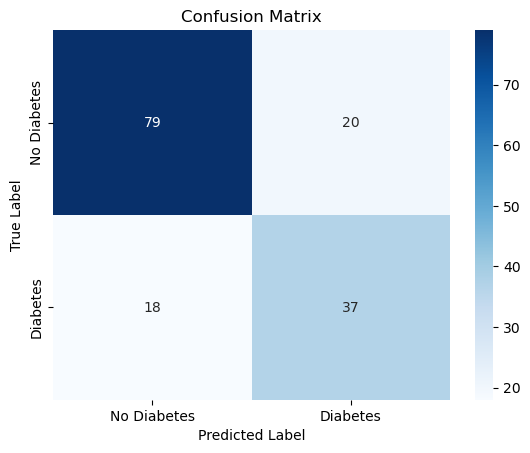

In [10]:
y_pred = nb_classifier.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Diabetes', 'Diabetes'], 
            yticklabels=['No Diabetes', 'Diabetes'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

### Exploring Log Probabilities in Naïve Bayes

Naive Bayes calculates log probabilities (logprobs) for each class to make predictions. Let's use `predict_log_proba` to calculate the log probabilities for each class (diabetes vs. no diabetes) for a few samples in the test set.

Question: For a given instance in the test set, calculate the log probabilities for each class (diabetes vs. no diabetes) and interpret the values. How does Naive Bayes decide the predicted class based on these log probabilities?

In [16]:
# Convert log probabilities back to regular probabilities
log_probs_test = nb_classifier.predict_log_proba(X_test)
probabilities_raw = np.exp(log_probs_test)

# Adjusting the threshold to favor Recall (making it 'easier' to be classified as 1)
threshold = 0.2

probabilities_list = []
for i, index in enumerate(X_test.index):
    # If the probability of Class 1 (Diabetes) is >= threshold, predict 1
    prob_diabetes = probabilities_raw[i][1]
    prediction = 1 if prob_diabetes >= threshold else 0
    
    probabilities_list.append({
        'index': index, 
        'no_diab_prob': probabilities_raw[i][0], 
        'diab_prob': prob_diabetes, 
        'prediction': prediction
    })

probabilities_df = pd.DataFrame(probabilities_list)
print(probabilities_df.head())

# Re-evaluate with the adjusted threshold
y_pred_adjusted = probabilities_df['prediction']
print("\nAdjusted Recall:", recall_score(y_test, y_pred_adjusted))
print("Adjusted Precision:", precision_score(y_test, y_pred_adjusted))

   index  no_diab_prob  diab_prob  prediction
0    668      0.798057   0.201943           1
1    324      0.925291   0.074709           0
2    624      0.974861   0.025139           0
3    690      0.803488   0.196512           0
4    473      0.375673   0.624327           1

Adjusted Recall: 0.9090909090909091
Adjusted Precision: 0.5813953488372093


- Interpretation of Log Probabilities: Log probabilities represent the logarithm of the probability for each class. A higher log probability (closer to zero, since log values are negative) indicates a higher likelihood for that class.
- Decision-Making: The model predicts the class with the highest log probability. If the log probability for Diabetes (1) is higher (closer to zero) than for No Diabetes (0), the model will predict Diabetes (1).

Convert log probabilities back to regular probabilities using np.exp(log_probs) to see how log transformations aid computation without changing predictions.

In [17]:
# 1. Calculate log probabilities (we already did this, but let's be explicit)
log_probs = nb_classifier.predict_log_proba(X_test)

# 2. Convert log probabilities back to regular probabilities using np.exp()
# np.exp() is the inverse of the natural log
probabilities_regular = np.exp(log_probs)

# 3. Compare them to show they don't change the decision
print("First 5 samples - Log Probabilities (Class 0, Class 1):")
print(log_probs[:5])

print("\nFirst 5 samples - Regular Probabilities (Class 0, Class 1):")
print(probabilities_regular[:5])

# Verification: Does the highest log_prob match the highest regular_prob?
# We use argmax to find the index (0 or 1) of the highest value
log_predictions = np.argmax(log_probs, axis=1)
reg_predictions = np.argmax(probabilities_regular, axis=1)

print(f"\nAre the predictions identical? {np.array_equal(log_predictions, reg_predictions)}")

First 5 samples - Log Probabilities (Class 0, Class 1):
[[-0.22557567 -1.59976815]
 [-0.07764708 -2.59415368]
 [-0.02546084 -3.68331716]
 [-0.21879263 -1.62703342]
 [-0.97903596 -0.47108115]]

First 5 samples - Regular Probabilities (Class 0, Class 1):
[[0.79805667 0.20194333]
 [0.92529092 0.07470908]
 [0.97486056 0.02513944]
 [0.80348832 0.19651168]
 [0.37567309 0.62432691]]

Are the predictions identical? True


Change your decision treshold so that either class 1 or 0 becomes more frequent in order to optimize your preferred metric (precision or recall) for this problem. Try multiple tresholds until you are satisfied with your choice.

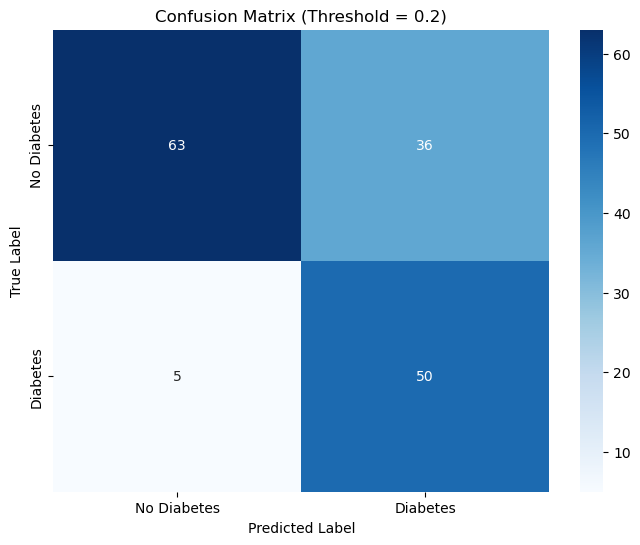

   index  no_diab_prob  diab_prob  prediction
0    668      0.798057   0.201943           1
1    324      0.925291   0.074709           0
2    624      0.974861   0.025139           0
3    690      0.803488   0.196512           0
4    473      0.375673   0.624327           1


In [27]:
# 1. Ensure we have the latest probabilities from the model
log_probs = nb_classifier.predict_log_proba(X_test)
probabilities_raw = np.exp(log_probs)

# 2. Re-build the results list
threshold = 0.2 # Fixed typo from 'treshold'
results_list = []

for i, index in enumerate(X_test.index):
    prob_0 = probabilities_raw[i][0]
    prob_1 = probabilities_raw[i][1] 
    prediction = 1 if prob_1 >= threshold else 0
    
    results_list.append({
        'index': index,
        'no_diab_prob': prob_0, 
        'diab_prob': prob_1, 
        'prediction': prediction
    })

# 3. Convert to DataFrame
probabilities_df = pd.DataFrame(results_list)

# 4. Create the confusion matrix using the CORRECT variable name
y_pred_adjusted = probabilities_df['prediction'] # Changed from 'probabilities'
cm = confusion_matrix(y_test, y_pred_adjusted)

# 5. Plotting
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Diabetes', 'Diabetes'], 
            yticklabels=['No Diabetes', 'Diabetes'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title(f"Confusion Matrix (Threshold = {threshold})")
plt.show()

print(probabilities_df.head())